# Machine Learning Concepts - A Gentle Overview

Before we start building actual models in the next notebook, it is worth taking some time to understand the words people use around this subject. Terms like *AI*, *machine learning*, *data science*, *supervised learning*, and *deep learning* often get used as if they were the same thing. They are related, but they are not interchangeable.

This notebook is mostly about ideas. There is some code, but only enough to make a few of the concepts concrete. We will cover:

1. The DIKW hierarchy: data, information, knowledge, and wisdom.
2. What artificial intelligence is, and how machine learning fits inside it.
3. What data science is, and how it overlaps with machine learning.
4. The three main types of machine learning: supervised, unsupervised, and reinforcement learning.
5. Common terms you will keep hearing: features, labels, training, testing, model, generalisation.
6. A short note on where deep learning fits in.

Take your time with the diagrams and tables. Most of the confusion in this field is just confusion about vocabulary.


## Setup

We will only need a few libraries for the small examples below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

rng = np.random.default_rng(42)

print("Libraries loaded.")


Libraries loaded.


## 1. Data, Information, Knowledge, Wisdom

Before we talk about machine learning we should be careful about the word *data*. Data on its own is rarely useful. There is a classical pyramid called the **DIKW hierarchy** that explains how raw numbers gradually become something we can act on.

| Level | What it is | Example from a college |
|-------|------------|------------------------|
| Data | Raw facts and figures with no context. | `72, 65, 88, 54, 90` |
| Information | Data that has been organised or labelled. | "These are the marks of five students in the Statistics exam." |
| Knowledge | Information combined with experience and understanding. | "Most students who score below 60 struggled with the inferential part of the syllabus." |
| Wisdom | Knowledge applied to make good decisions. | "Next semester we should spend an extra week on hypothesis testing before the mid-term." |

Machine learning operates mostly in the lower three levels. It takes data, organises it into information, and learns rules from that information that we can think of as a kind of knowledge. Whether we apply those rules wisely is still a human responsibility.


In [2]:
# A small demonstration of the difference between data and information.

# Pure data: just numbers, no meaning.
raw_numbers = [72, 65, 88, 54, 90, 61, 77, 83, 49, 70]
print("Data (just numbers):")
print(raw_numbers)

# Information: the same numbers organised and labelled.
df = pd.DataFrame({
    "student": [f"S{i:02d}" for i in range(1, 11)],
    "subject": ["Statistics"] * 10,
    "marks":   raw_numbers,
})
print("\nInformation (organised, labelled, in context):")
print(df)

# A small piece of knowledge we can extract from the information.
print(f"\nKnowledge: average marks = {df['marks'].mean():.1f}, "
      f"and {(df['marks'] < 60).sum()} students scored below 60.")


Data (just numbers):
[72, 65, 88, 54, 90, 61, 77, 83, 49, 70]

Information (organised, labelled, in context):
  student     subject  marks
0     S01  Statistics     72
1     S02  Statistics     65
2     S03  Statistics     88
3     S04  Statistics     54
4     S05  Statistics     90
5     S06  Statistics     61
6     S07  Statistics     77
7     S08  Statistics     83
8     S09  Statistics     49
9     S10  Statistics     70

Knowledge: average marks = 70.9, and 2 students scored below 60.


## 2. Artificial Intelligence, Machine Learning, Deep Learning

These three terms are often used loosely. The simplest way to keep them straight is to remember that they are nested inside each other.

**Artificial Intelligence (AI)** is the broadest term. It refers to any technique that allows a computer to do things that we would normally consider intelligent: solving puzzles, understanding language, recognising images, playing games, planning routes, and so on. AI is older than most people think; it has existed as an academic field since the 1950s.

**Machine Learning (ML)** is a subset of AI. Instead of programming rules by hand, we give the computer many examples and let it figure out the rules itself. A spam filter that learns from past emails is an ML system; an old spam filter that uses a hand-written list of "bad words" is just classical AI.

**Deep Learning (DL)** is a subset of ML. It uses a particular family of models called *neural networks* with many layers. It is responsible for most of the recent excitement: image recognition, voice assistants, large language models, and so on.

```
+---------------------------------------------------+
|  Artificial Intelligence                          |
|  +---------------------------------------------+  |
|  |  Machine Learning                           |  |
|  |  +---------------------------------------+  |  |
|  |  |  Deep Learning                        |  |  |
|  |  +---------------------------------------+  |  |
|  +---------------------------------------------+  |
+---------------------------------------------------+
```

A useful sentence to remember:

> All deep learning is machine learning, and all machine learning is artificial intelligence, but not the other way around.


## 3. Where does Data Science fit in?

Data science is a slightly different beast. It is less a single technique and more a collection of skills used to work with data end to end. A typical data scientist's day might involve:

- Collecting data from databases, APIs, or files.
- Cleaning and reshaping that data.
- Exploring it visually to understand what is there.
- Applying statistics or machine learning to answer a question.
- Communicating the results to people who are not programmers.

The Venn diagram people usually draw looks like this:

```
                Mathematics & Statistics
                          /\
                         /  \
                        /    \
   Computer Science ---|  DS  |--- Domain Knowledge
                        \    /
                         \  /
                          \/
```

Machine learning sits inside this picture as one of the tools a data scientist might use. Some data science problems do not need machine learning at all - a well-made dashboard or a careful statistical test is often enough.

| Discipline | Main question |
|------------|---------------|
| Statistics | What does this data tell us, and how confident can we be? |
| Machine learning | Can a computer learn to predict or classify from this data? |
| Data science | What is the practical answer to the business or research question? |
| Artificial intelligence | Can a machine behave intelligently in this task? |


## 4. Types of Machine Learning

Machine learning is usually split into three big families based on what kind of data is available and what the goal is.

### 4.1 Supervised learning

In supervised learning the data comes with a known answer for each example, called a **label**. The model's job is to learn the relationship between the inputs and the labels well enough to make predictions on new, unseen examples.

Two common sub-types:

| Sub-type | Predicts | Example |
|----------|----------|---------|
| Regression | A number | Predicting house price from house size. |
| Classification | A category | Predicting whether an email is spam. |

Most of this course is about supervised learning.

### 4.2 Unsupervised learning

In unsupervised learning, there are no labels. The model is given a pile of data and is asked to find structure in it on its own.

| Sub-type | Goal | Example |
|----------|------|---------|
| Clustering | Group similar items together | Grouping customers by behaviour. |
| Dimensionality reduction | Compress data while keeping what matters | Visualising high-dimensional data on a 2-D plot. |
| Association | Find rules that often hold together | "People who buy bread often also buy butter." |

### 4.3 Reinforcement learning

Reinforcement learning is different again. There is an **agent** that acts in an **environment**. After each action the agent receives a numeric **reward** (or punishment) and the environment moves to a new state. The agent's job is to learn a strategy that earns the most reward over time.

Examples:

- A program that learns to play chess by playing millions of games against itself.
- A robot that learns to walk by trying actions and being rewarded for moving forward.
- A recommendation system that learns to suggest videos you are likely to watch next.

The key contrast: supervised learning is told the right answer for every example; reinforcement learning has to discover good behaviour through trial and error.


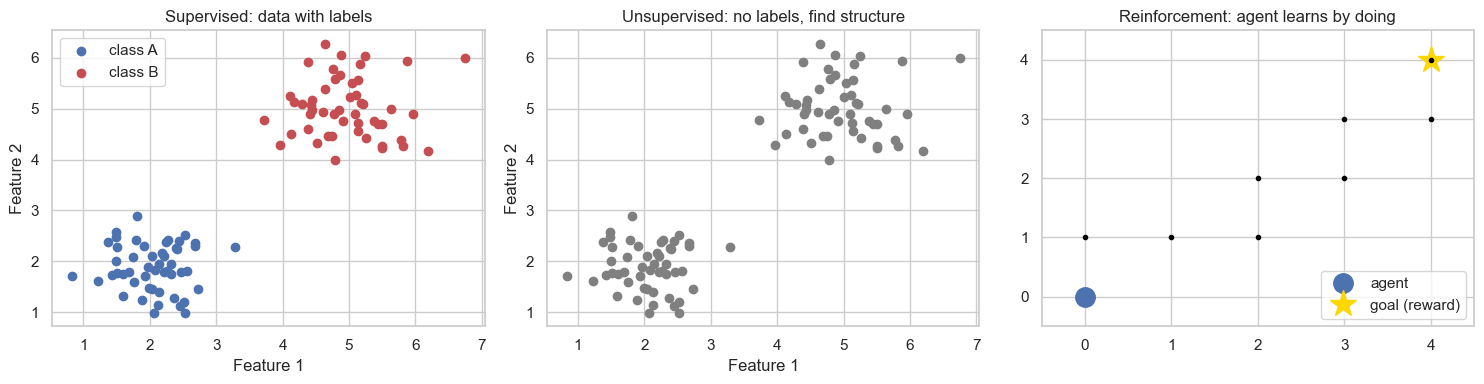

In [3]:
# A small picture to compare the three families.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Supervised: two clearly labelled groups.
x_a = rng.normal(2, 0.6, 50); y_a = rng.normal(2, 0.6, 50)
x_b = rng.normal(5, 0.6, 50); y_b = rng.normal(5, 0.6, 50)
axes[0].scatter(x_a, y_a, color="#4C72B0", label="class A")
axes[0].scatter(x_b, y_b, color="#C44E52", label="class B")
axes[0].set_title("Supervised: data with labels")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")
axes[0].legend()

# Unsupervised: same data points, but unlabelled.
axes[1].scatter(np.r_[x_a, x_b], np.r_[y_a, y_b], color="grey")
axes[1].set_title("Unsupervised: no labels, find structure")
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")

# Reinforcement: a small grid where an agent moves towards a goal.
axes[2].set_xlim(-0.5, 4.5); axes[2].set_ylim(-0.5, 4.5)
axes[2].set_xticks(range(5)); axes[2].set_yticks(range(5))
axes[2].grid(True)
axes[2].plot(0, 0, "o", color="#4C72B0", markersize=14, label="agent")
axes[2].plot(4, 4, "*", color="gold", markersize=20, label="goal (reward)")
for x, y in [(0,1),(1,1),(2,1),(2,2),(3,2),(3,3),(4,3),(4,4)]:
    axes[2].plot(x, y, ".", color="black")
axes[2].set_title("Reinforcement: agent learns by doing")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()


These three pictures roughly correspond to the three learning settings:

- *Supervised*: every point has a colour (a label). The job is to learn the boundary.
- *Unsupervised*: no colours. The job is to notice that there are two natural groups.
- *Reinforcement*: an agent navigating a small world, rewarded only when it reaches the goal.


## 5. Common Vocabulary

Here are the terms that show up over and over again in this field. Spend a few minutes here; the rest of the course will be much easier if these are familiar.

| Term | Meaning |
|------|---------|
| Dataset | A collection of examples we will learn from. |
| Sample / Instance / Row | One example in the dataset. |
| Feature / Attribute / Input | A property of an example used to make predictions. |
| Label / Target / Output | The answer we want to predict (only in supervised learning). |
| Model | The mathematical object we train to make predictions. |
| Algorithm | The recipe used to fit the model to the data. |
| Training set | The portion of the data the model learns from. |
| Test set | A separate portion held back to evaluate how well the model has learned. |
| Validation set | A third portion used to tune choices like the learning rate. |
| Prediction | The model's output on a new input. |
| Loss / Error | A number that measures how wrong the model's predictions are. |
| Overfitting | The model memorised the training data and does poorly on new data. |
| Underfitting | The model is too simple and misses real patterns even on the training data. |
| Generalisation | How well the model performs on new, unseen examples. |

The single most important idea here is the difference between **training** and **testing**. We never judge a model only by how well it does on the data it was trained on. We always hold some data back, and the model's score on that held-back data is what we trust.


In [4]:
# A toy dataset: hours studied (feature) and whether the student passed (label).
hours = rng.uniform(0, 10, size=20).round(1)
passed = (hours + rng.normal(0, 1.5, size=20) > 5).astype(int)

df = pd.DataFrame({"hours_studied": hours, "passed": passed})
print("First few rows of our toy dataset:")
print(df.head())

print("\nIn the language of this section:")
print(f"  Number of samples (rows)   : {len(df)}")
print(f"  Feature (input)            : 'hours_studied'")
print(f"  Label   (target output)    : 'passed' (1 = yes, 0 = no)")

# A simple 70/30 train-test split.
train = df.sample(frac=0.7, random_state=0)
test  = df.drop(train.index)
print(f"\nTraining set size : {len(train)}")
print(f"Test set size     : {len(test)}")


First few rows of our toy dataset:
   hours_studied  passed
0            0.1       0
1            2.3       0
2            1.3       0
3            6.8       1
4            1.2       0

In the language of this section:
  Number of samples (rows)   : 20
  Feature (input)            : 'hours_studied'
  Label   (target output)    : 'passed' (1 = yes, 0 = no)

Training set size : 14
Test set size     : 6


## 6. A first look at overfitting and underfitting

Overfitting is one of the most important ideas in machine learning, so it is worth seeing it once visually. We will fit three models of increasing complexity to the same noisy data:

- A straight line (too simple, *underfits*).
- A smooth curve (about right).
- A wiggly curve that passes through every point (memorises noise, *overfits*).


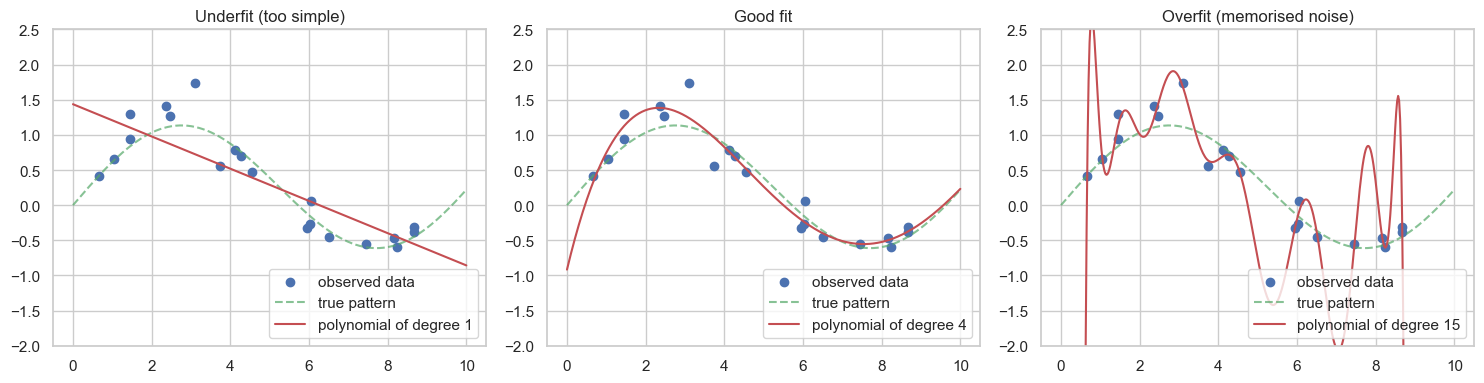

In [5]:
# Generate noisy data from a smooth underlying curve.
xs_true = np.linspace(0, 10, 200)
ys_true = np.sin(xs_true * 0.6) + 0.05 * xs_true

xs = rng.uniform(0, 10, size=20)
ys = np.sin(xs * 0.6) + 0.05 * xs + rng.normal(0, 0.3, size=len(xs))

# Fit polynomials of three different degrees.
degrees = [1, 4, 15]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, deg in zip(axes, degrees):
    coeffs = np.polyfit(xs, ys, deg=deg)
    fit = np.poly1d(coeffs)
    grid = np.linspace(0, 10, 400)

    ax.scatter(xs, ys, color="#4C72B0", label="observed data")
    ax.plot(xs_true, ys_true, "g--", alpha=0.7, label="true pattern")
    ax.plot(grid, fit(grid), "r-", label=f"polynomial of degree {deg}")
    ax.set_ylim(-2, 2.5)
    ax.set_title({1: "Underfit (too simple)",
                  4: "Good fit",
                  15: "Overfit (memorised noise)"}[deg])
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


Look at the three plots:

- The straight line on the left is too rigid. It cannot capture the curve at all. This is **underfitting**.
- The middle curve roughly tracks the true underlying pattern, ignoring the noise. This is what we want.
- The wiggly curve on the right passes very close to every observed point, but it has to twist wildly to do so. On new data drawn from the same process, it would probably do worse than the middle curve. This is **overfitting**.

The whole game of building good models is finding that middle ground - flexible enough to learn real patterns, but not so flexible that it learns the noise. We will see formal techniques for this in `Regularization&Metrics.ipynb`.


## 7. A typical machine learning workflow

Almost every applied ML project follows the same broad sequence of steps. The exact details vary, but the shape is consistent.

1. **Define the problem.** What question are we actually trying to answer? Is it a regression task, a classification task, or something else?
2. **Collect data.** From databases, APIs, files, or experiments.
3. **Clean and prepare the data.** Handle missing values, fix obvious errors, convert text to numbers, and so on.
4. **Explore the data.** Plot histograms, compute summary statistics, look for patterns. This is where descriptive statistics earns its keep.
5. **Split the data** into training and test sets. Always do this *before* you start fitting models.
6. **Choose a model** appropriate for the problem.
7. **Train the model** on the training set.
8. **Evaluate the model** on the test set. If the score is poor, go back and try a different model or different features.
9. **Deploy the model** so other people or systems can use it.
10. **Monitor and update.** Real-world data drifts over time, so models need to be checked and retrained.

Notice that *most* of the work is not the modelling step. Practising data scientists routinely report that 60-80% of their time is spent on data preparation.


## 8. How this notebook connects to the rest of the course

Think of this notebook as a glossary you can come back to. Here is how the pieces line up:

| Concept introduced here | Notebook where it is used in detail |
|--------------------------|-------------------------------------|
| Data, information, knowledge | `StatisticsFoundations.ipynb` |
| Supervised learning, regression | `LinearRegression.ipynb` |
| How models learn parameters | `ParameterEstimation.ipynb` |
| Overfitting, train/test split, model metrics | `Regularization&Metrics.ipynb` |

For now you do not need to remember every word in the table earlier in this notebook. As you meet each term again in context, it will start to feel natural. Vocabulary in this field is best learned by use, not memorisation.

When you are ready, move on to `LinearRegression.ipynb`, where we will turn these concepts into our first proper model.


## 9. Quick check

A few short questions to test your understanding. Try to answer them before peeking at the answers.

1. A bank wants to flag whether a transaction is fraudulent based on past examples of fraudulent and legitimate transactions. Is this supervised, unsupervised, or reinforcement learning? What sub-type?
2. A streaming service wants to group its users into similar listening profiles, with no pre-defined categories. Which family of learning is this?
3. A self-driving car learns to take better routes by being rewarded when it arrives faster and safely. Which family of learning is this?
4. Is "the average exam score is 72" data, information, or knowledge?
5. Which of the following is *not* always true?
   - (a) All deep learning is machine learning.
   - (b) All machine learning is artificial intelligence.
   - (c) All artificial intelligence is machine learning.

*Answers:*

1. *Supervised learning, classification (the labels are "fraud" / "not fraud").*
2. *Unsupervised learning, specifically clustering.*
3. *Reinforcement learning.*
4. *Information. Raw scores would be data; an explanation of why students did poorly would be closer to knowledge.*
5. *(c) is the false one. Plenty of classical AI techniques, like rule-based expert systems, do not learn from data at all.*
